<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## LSTM Traductor
Ejemplo basado en [LINK](https://stackabuse.com/python-for-nlp-neural-machine-translation-with-seq2seq-in-keras/)

### Datos
El objecto es utilizar datos disponibles del Tatoeba Project de traducciones de texto en diferentes idiomas. Se construirá un modelo traductor de inglés a español seq2seq utilizando encoder-decoder.\
[LINK](https://www.manythings.org/anki/)

In [457]:
import re

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Dense
from tensorflow.keras.layers import Flatten, LSTM, SimpleRNN
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Input
from tensorflow.keras.utils import plot_model

In [458]:
# dataset_file

text_file = "./spa-eng/spa.txt"
with open(text_file) as f:
    lines = f.read().split("\n")[:-1]

# Por limitaciones de RAM no se leen todas las filas
MAX_NUM_SENTENCES = 7000

# Mezclar el dataset, forzar semilla siempre igual
np.random.seed([40])
np.random.shuffle(lines)

input_sentences = []
output_sentences = []
output_sentences_inputs = []
count = 0

for line in lines:
    count += 1
    if count > MAX_NUM_SENTENCES:
        break

    # el tabulador señaliza la separación entre las oraciones 
    # en ambos idiomas
    if '\t' not in line: 
        continue

    # Input sentence --> eng
    # output --> spa
    input_sentence, output = line.rstrip().split('\t')

    # output sentence (decoder_output) tiene <eos>
    output_sentence = output + ' <eos>'
    # output sentence input (decoder_input) tiene <sos>
    output_sentence_input = '<sos> ' + output

    input_sentences.append(input_sentence)
    output_sentences.append(output_sentence)
    output_sentences_inputs.append(output_sentence_input)

print("Cantidad de rows disponibles:", len(lines))
print("Cantidad de rows utilizadas:", len(input_sentences))

Cantidad de rows disponibles: 118964
Cantidad de rows utilizadas: 7000


In [459]:
input_sentences[0], output_sentences[0], output_sentences_inputs[0]

('A deal is a deal.',
 'Un trato es un trato. <eos>',
 '<sos> Un trato es un trato.')

### 2 - Preprocesamiento

In [460]:
# Definir el tamaño máximo del vocabulario
MAX_VOCAB_SIZE = 8000
# Vamos a necesitar un tokenizador para cada idioma

In [461]:
# Tokenizar las palabras con el Tokenizer de Keras
# Definir una máxima cantidad de palabras a utilizar:
# - num_words --> the maximum number of words to keep, based on word frequency.
# - Only the most common num_words-1 words will be kept.
from tensorflow.keras.preprocessing.text import Tokenizer

# tokenizador de inglés
input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)

word2idx_inputs = input_tokenizer.word_index
print("Palabras en el vocabulario:", len(word2idx_inputs))

max_input_len = max(len(sen) for sen in input_integer_seq)
print("Sentencia de entrada más larga:", max_input_len)

Palabras en el vocabulario: 4153
Sentencia de entrada más larga: 32


In [462]:
# tokenizador de español
# A los filtros de símbolos del Tokenizer agregamos el "¿",
# sacamos los "<>" para que no afectar nuestros tokens
output_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n')
output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)

word2idx_outputs = output_tokenizer.word_index
print("Palabras en el vocabulario:", len(word2idx_outputs))

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE) 
# Se suma 1 para incluir el token de palabra desconocida

max_out_len = max(len(sen) for sen in output_integer_seq)
print("Sentencia de salida más larga:", max_out_len)

Palabras en el vocabulario: 6246
Sentencia de salida más larga: 36


Como era de esperarse, las sentencias en castellano son más largas que en inglés, y lo mismo sucede con su vocabulario.

In [463]:
# Por una cuestion de que no explote la RAM se limitará el tamaño de las sentencias de entrada
# a la mitad:
max_input_len = 20
max_out_len = 36

A la hora de realiza padding es importante tener en cuenta que en el encoder los ceros se agregan al comienzo y en el decoder al final. Esto es porque la salida del encoder está basado en las últimas palabras de la sentencia (son las más importantes), mientras que en el decoder está basado en el comienzo de la secuencia de salida ya que es la realimentación del sistema y termina con fin de sentencia.

In [464]:
print("Cantidad de rows del dataset:", len(input_integer_seq))

encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=max_input_len)
print("encoder_input_sequences shape:", encoder_input_sequences.shape)

decoder_input_sequences = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
print("decoder_input_sequences shape:", decoder_input_sequences.shape)

Cantidad de rows del dataset: 7000
encoder_input_sequences shape: (7000, 20)
decoder_input_sequences shape: (7000, 36)


La última capa del modelo (softmax) necesita que los valores de salida
del decoder (decoder_sequences) estén en formato oneHotEncoder.\
Se utiliza "decoder_output_sequences" con la misma estrategia con que se transformó la entrada del decoder.

In [465]:
from keras.utils import to_categorical
decoder_output_sequences = pad_sequences(output_integer_seq, maxlen=max_out_len, padding='post')
decoder_targets = to_categorical(decoder_output_sequences, num_classes=num_words_output)
decoder_targets.shape

(7000, 36, 6247)

### 3 - Preparar los embeddings

In [466]:
# Descargar los embeddings desde un google drive (es la forma más rápida)
# NOTA: No hay garantía de que estos links perduren, en caso de que no estén
# disponibles descargar de la página oficial como se explica en el siguiente bloque de código
import os
import gdown
if os.access('gloveembedding.pkl', os.F_OK) is False:
    url = 'https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&export=download'
    output = 'gloveembedding.pkl'
    gdown.download(url, output, quiet=False)
else:
    print("Los embeddings gloveembedding.pkl ya están descargados")

Los embeddings gloveembedding.pkl ya están descargados


In [467]:
# En caso de que gdown de algún error de permisos intentar descargar los
# embeddings con curl:

!curl -L -o 'gloveembedding.pkl' 'https://drive.google.com/u/0/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&export=download&confirm=t'

curl: (3) URL rejected: Port number was not a decimal number between 0 and 65535
"export" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"confirm" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [468]:
import logging
import os
from pathlib import Path
from io import StringIO
import pickle

class WordsEmbeddings(object):
    logger = logging.getLogger(__name__)

    def __init__(self):
        # load the embeddings
        words_embedding_pkl = Path(self.PKL_PATH)
        if not words_embedding_pkl.is_file():
            words_embedding_txt = Path(self.WORD_TO_VEC_MODEL_TXT_PATH)
            assert words_embedding_txt.is_file(), 'Words embedding not available'
            embeddings = self.convert_model_to_pickle()
        else:
            embeddings = self.load_model_from_pickle()
        self.embeddings = embeddings
        # build the vocabulary hashmap
        index = np.arange(self.embeddings.shape[0])
        # Dicctionarios para traducir de embedding a IDX de la palabra
        self.word2idx = dict(zip(self.embeddings['word'], index))
        self.idx2word = dict(zip(index, self.embeddings['word']))

    def get_words_embeddings(self, words):
        words_idxs = self.words2idxs(words)
        return self.embeddings[words_idxs]['embedding']

    def words2idxs(self, words):
        return np.array([self.word2idx.get(word, -1) for word in words])

    def idxs2words(self, idxs):
        return np.array([self.idx2word.get(idx, '-1') for idx in idxs])

    def load_model_from_pickle(self):
        self.logger.debug(
            'loading words embeddings from pickle {}'.format(
                self.PKL_PATH
            )
        )
        max_bytes = 2**28 - 1 # 256MB
        bytes_in = bytearray(0)
        input_size = os.path.getsize(self.PKL_PATH)
        with open(self.PKL_PATH, 'rb') as f_in:
            for _ in range(0, input_size, max_bytes):
                bytes_in += f_in.read(max_bytes)
        embeddings = pickle.loads(bytes_in)
        self.logger.debug('words embeddings loaded')
        return embeddings

    def convert_model_to_pickle(self):
        # create a numpy strctured array:
        # word     embedding
        # U50      np.float32[]
        # word_1   a, b, c
        # word_2   d, e, f
        # ...
        # word_n   g, h, i
        self.logger.debug(
            'converting and loading words embeddings from text file {}'.format(
                self.WORD_TO_VEC_MODEL_TXT_PATH
            )
        )
        structure = [('word', np.dtype('U' + str(self.WORD_MAX_SIZE))),
                     ('embedding', np.float32, (self.N_FEATURES,))]
        structure = np.dtype(structure)
        # load numpy array from disk using a generator
        with open(self.WORD_TO_VEC_MODEL_TXT_PATH, encoding="utf8") as words_embeddings_txt:
            embeddings_gen = (
                (line.split()[0], line.split()[1:]) for line in words_embeddings_txt
                if len(line.split()[1:]) == self.N_FEATURES
            )
            embeddings = np.fromiter(embeddings_gen, structure)
        # add a null embedding
        null_embedding = np.array(
            [('null_embedding', np.zeros((self.N_FEATURES,), dtype=np.float32))],
            dtype=structure
        )
        embeddings = np.concatenate([embeddings, null_embedding])
        # dump numpy array to disk using pickle
        max_bytes = 2**28 - 1 # # 256MB
        bytes_out = pickle.dumps(embeddings, protocol=pickle.HIGHEST_PROTOCOL)
        with open(self.PKL_PATH, 'wb') as f_out:
            for idx in range(0, len(bytes_out), max_bytes):
                f_out.write(bytes_out[idx:idx+max_bytes])
        self.logger.debug('words embeddings loaded')
        return embeddings


class GloveEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = 'glove.twitter.27B.50d.txt'
    PKL_PATH = 'gloveembedding.pkl'
    N_FEATURES = 50
    WORD_MAX_SIZE = 60

class FasttextEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = 'cc.en.300.vec'
    PKL_PATH = 'fasttext.pkl'
    N_FEATURES = 300
    WORD_MAX_SIZE = 60

In [469]:
# Por una cuestion de RAM se utilizarán los embeddings de Glove de dimension 50
model_embeddings = GloveEmbeddings()

In [470]:
# Crear la Embedding matrix de las secuencias
# en inglés

print('preparing embedding matrix...')
embed_dim = model_embeddings.N_FEATURES
words_not_found = []

# word_index provieen del tokenizer

nb_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs)) # vocab_size
max_encoder_idx = encoder_input_sequences.max()
nb_words = max(nb_words, max_encoder_idx + 1)  # +1 porque los índices van de 0 a max

embedding_matrix = np.zeros((nb_words, embed_dim))
print("nb_words:", nb_words)
for word, i in word2idx_inputs.items():
    if i >= nb_words:
        continue
    embedding_vector = model_embeddings.get_words_embeddings(word)[0]
    if (embedding_vector is not None) and len(embedding_vector) > 0:
        
        embedding_matrix[i] = embedding_vector
    else:
        # words not found in embedding index will be all-zeros.
        words_not_found.append(word)

print('number of null word embeddings:', np.sum(np.sum(embedding_matrix**2, axis=1) == 0))

preparing embedding matrix...
nb_words: 4154
number of null word embeddings: 38


In [471]:
# Dimensión de los embeddings de la secuencia en inglés
embedding_matrix.shape

(4154, 50)

### 4 - Entrenar el modelo

In [472]:
max_input_len

20

In [473]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.optimizers import Adam

n_units = 128

# define training encoder
encoder_inputs = Input(shape=(max_input_len,))

#encoder_embedding_layer = Embedding(num_words, EMBEDDING_SIZE, weights=[embedding_matrix], input_length=max_input_len)

encoder_embedding_layer = Embedding(
          input_dim=nb_words,  # definido en el Tokenizador
          output_dim=embed_dim,  # dimensión de los embeddings utilizados
          input_length=max_input_len, # tamaño máximo de la secuencia de entrada
          weights=[embedding_matrix],  # matrix de embeddings
          trainable=False)      # marcar como layer no entrenable

encoder_inputs_x = encoder_embedding_layer(encoder_inputs)

encoder = LSTM(n_units, return_state=True, dropout=0.3)
encoder_outputs, state_h, state_c = encoder(encoder_inputs_x)
encoder_states = [state_h, state_c]

# define training decoder
decoder_inputs = Input(shape=(max_out_len,))
decoder_embedding_layer = Embedding(
    input_dim=num_words_output, 
    output_dim=n_units, 
    input_length=max_out_len
)
decoder_inputs_x = decoder_embedding_layer(decoder_inputs)

decoder_lstm = LSTM(n_units, return_sequences=True, return_state=True, dropout=0.3)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs_x, initial_state=encoder_states)

# Dense
decoder_dense = Dense(num_words_output, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

# Crear optimizador con learning rate específico
optimizer = Adam(learning_rate=0.001)

model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
model.summary()

c:\Users\jonat\anaconda3\envs\ia_env\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_43"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_80      │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_81      │ (None, 36)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_34        │ (None, 20, 50)    │    207,700 │ input_layer_80[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_35        │ (None, 36, 128)   │    799,616 │ input_layer_81[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_33 (LSTM)      │ [(None, 128),     │     91,648 │ embedding_34[0][… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_34 (LSTM)      │ [(None, 36, 128), │    131,584 │ embedding_35[0][… │
│                     │ (None, 128),      │            │ lstm_33[0][1],    │
│                     │ (None, 128)]      │            │ lstm_33[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 36, 6247)  │    805,863 │ lstm_34[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,036,411 (7.77 MB)

 Trainable params: 1,828,711 (6.98 MB)

 Non-trainable params: 207,700 (811.33 KB)

In [474]:
# Modelo completo (encoder+decoder) para poder entrenar
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [475]:
# Modelo solo encoder

# define inference encoder
encoder_model = Model(encoder_inputs, encoder_states)

plot_model(encoder_model, to_file='encoder_plot.png', show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [476]:
# Modelo solo decoder (para realizar inferencia)

# define inference decoder
decoder_state_input_h = Input(shape=(n_units,))
decoder_state_input_c = Input(shape=(n_units,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# En cada predicción habrá una sola palabra de entrada al decoder,
# que es la realimentación de la palabra anterior
# por lo que hay que modificar el input shape de la layer de Embedding
decoder_inputs_single = Input(shape=(1,))
decoder_inputs_single_x = decoder_embedding_layer(decoder_inputs_single)

decoder_outputs, state_h, state_c = decoder_lstm(decoder_inputs_single_x, initial_state=decoder_states_inputs)
decoder_states = [state_h, state_c]
decoder_outputs = decoder_dense(decoder_outputs)
decoder_model = Model([decoder_inputs_single] + decoder_states_inputs, [decoder_outputs] + decoder_states)

plot_model(decoder_model, to_file='decoder_plot.png', show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [477]:
hist = model.fit(
    [encoder_input_sequences, decoder_input_sequences],
    decoder_targets,
    epochs=100, 
    validation_split=0.2)

Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.8020 - loss: 2.1393 - val_accuracy: 0.8320 - val_loss: 1.2179
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.8325 - loss: 1.1794 - val_accuracy: 0.8375 - val_loss: 1.1579
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.8362 - loss: 1.1308 - val_accuracy: 0.8389 - val_loss: 1.1355
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.8377 - loss: 1.1008 - val_accuracy: 0.8425 - val_loss: 1.1193
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.8402 - loss: 1.0708 - val_accuracy: 0.8438 - val_loss: 1.1003
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.8428 - loss: 1.0392 - val_accuracy: 0.8463 - val_loss: 1.0828
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.8454 - loss: 1.0079 - val_accuracy: 0.8473 - val_loss: 1.0684
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.8470 - loss: 0

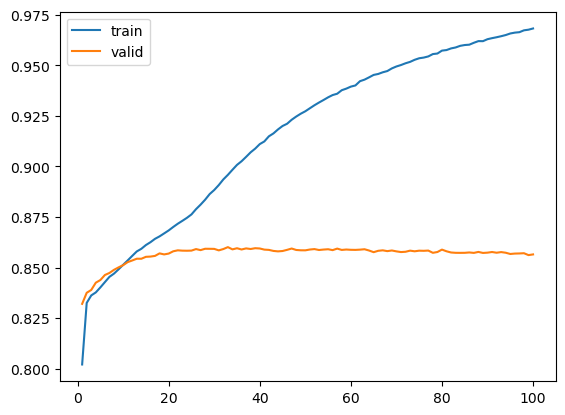

In [478]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(hist.history['accuracy']) + 1)
sns.lineplot(x=epoch_count,  y=hist.history['accuracy'], label='train')
sns.lineplot(x=epoch_count,  y=hist.history['val_accuracy'], label='valid')
plt.show()

**Nota de la ejecución:**  
La siguiente sección muestra una imagen generada durante el entrenamiento con:
```
MAX_NUM_SENTENCES = 7000
max_input_len = 20
max_out_len = 36
```

El modelo sigue con overfitting siendo que agrandé el número de sentencias usadas para el entrenamiento y el largo del output.

![Gráfico de accuracy durante 150 épocas (tamaño máximo 20)](../100epchos_2036max_size_03dropout.png)


**Nota de ejecuciones anteriores:**  
La siguiente sección muestra una imagen generada durante el entrenamiento con:
```
MAX_NUM_SENTENCES = 6000
max_input_len = 20
max_out_len = 20
```
Donde vemos que sin dropout hay mucho overfitting porque la validación se estanca:

![Gráfico de accuracy durante 150 épocas (tamaño máximo 20)](../150epchos_20max_size.png)


**Nota de ejecuciones anteriores:**  
La siguiente sección muestra una imagen generada durante el entrenamiento con:
```
MAX_NUM_SENTENCES = 6000
max_input_len = 20
max_out_len = 20
dropout = 0.3
```
Con dropout el modelo sigue con overfitting pero crece un poco más el accuracy de validación

![Gráfico de accuracy durante 150 épocas (tamaño máximo 20)](../60epchos_20max_size_03dropout.png)


### 5 - Inferencia

In [479]:
'''
Step 1:
A deal is a deal -> Encoder -> enc(h1,c1)

enc(h1,c1) + <sos> -> Decoder -> Un + dec(h1,c1)

step 2:
dec(h1,c1) + Un -> Decoder -> trato + dec(h2,c2)

step 3:
dec(h2,c2) + trato -> Decoder -> es + dec(h3,c3)

step 4:
dec(h3,c3) + es -> Decoder -> un + dec(h4,c4)

step 5:
dec(h4,c4) + un -> Decoder -> trato + dec(h5,c5)

step 6:
dec(h5,c5) + trato. -> Decoder -> <eos> + dec(h6,c6)
'''

'\nStep 1:\nA deal is a deal -> Encoder -> enc(h1,c1)\n\nenc(h1,c1) + <sos> -> Decoder -> Un + dec(h1,c1)\n\nstep 2:\ndec(h1,c1) + Un -> Decoder -> trato + dec(h2,c2)\n\nstep 3:\ndec(h2,c2) + trato -> Decoder -> es + dec(h3,c3)\n\nstep 4:\ndec(h3,c3) + es -> Decoder -> un + dec(h4,c4)\n\nstep 5:\ndec(h4,c4) + un -> Decoder -> trato + dec(h5,c5)\n\nstep 6:\ndec(h5,c5) + trato. -> Decoder -> <eos> + dec(h6,c6)\n'

In [480]:
# Armar los conversores de índice a palabra:
idx2word_input = {v:k for k, v in word2idx_inputs.items()}
idx2word_target = {v:k for k, v in word2idx_outputs.items()}

In [509]:
def translate_sentence(input_seq):
    # Se transforma la sequencia de entrada a los estados "h" y "c" de la LSTM
    # para enviar la primera vez al decoder
    states_value = encoder_model.predict(input_seq, verbose=False)

    # Se inicializa la secuencia de entrada al decoder como "<sos>"
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']

    # Se obtiene el índice que finaliza la inferencia
    eos = word2idx_outputs['<eos>']
    
    output_sentence = []
    for _ in range(max_out_len):
        # Predicción del próximo elemento
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=False)
        idx = np.argmax(output_tokens[0, 0, :])

        # Si es "end of sentece <eos>" se acaba
        if eos == idx:
            break

        # Transformar idx a palabra
        word = ''        
        if idx > 0:
            word = idx2word_target[idx]
            output_sentence.append(word)

        # Actualizar los estados dada la última predicción
        states_value = [h, c]

        # Actualizar secuencia de entrada con la salida (re-alimentación)
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)

In [537]:
for o in range(10):
    i = np.random.choice(len(input_sentences))
    input_seq = encoder_input_sequences[i:i+1]
    translation = translate_sentence(input_seq)
    print('-'*50)
    print('Input:   ', input_sentences[i])
    print('Response:', translation)
print('-'*50)

--------------------------------------------------
Input:    I was not disappointed.
Response: no bebo nunca vino
--------------------------------------------------
Input:    The thief ran away when he saw a policeman.
Response: tom se puso mucho que mary de mary estaba
--------------------------------------------------
Input:    I do not like science.
Response: no me gusta la ciencia
--------------------------------------------------
Input:    Aren't you guys sleepy?
Response: vas a salir o
--------------------------------------------------
Input:    I used to look up to him, but not anymore.
Response: solía admirarle pero no se cuece
--------------------------------------------------
Input:    He has been dead for five years.
Response: él ha estado aprendiendo alemán por un año
--------------------------------------------------
Input:    The room was illuminated with red lights.
Response: la empresa estaba en números
--------------------------------------------------
Input:    You'll

De las cadenas de texto tomadas de input_sentences que el modelo ya conoce, acierta en algunas pero falla en otras. Debería ser más preciso con estas frases.

```
Input:    I was not disappointed.

Response: no bebo nunca vino
```

❌ No traduce al input pero la frase tiene sentido.
```
Input:    The thief ran away when he saw a policeman.

Response: tom se puso mucho que mary de mary estaba
```

❌ No traduce al input ni genera una frase con sentido repitiendo "mary".
```
Input:    I do not like science.

Response: no me gusta la ciencia
```
✅ Traduce bien la frase.
```
Input:    Aren't you guys sleepy?

Response: vas a salir o
```

❌ No traduce al input ni genera una frase con sentido o por lo menos está cortada.
```
Input:    I used to look up to him, but not anymore.

Response: solía admirarle pero no se cuece
```
❌ Traduce al input pero a medias porque al final de la frase se empieza a confundir.
```
Input:    He has been dead for five years.

Response: él ha estado aprendiendo alemán por un año
```
--------------------------------------------------
❌ No traduce bien el input pero genera una frase con sentido.
```
Input:    The room was illuminated with red lights.

Response: la empresa estaba en números
```
--------------------------------------------------
❌ No traduce bien el input y la frase no tiene mucho sentido.
```
Input:    You'll never find it.

Response: nunca lo encontrarás
```

✅ Traduce bien la frase.
```
Input:    My students have been eagerly awaiting the test results.

Response: mi padre me ha sentido bien desde la operación
```
❌ No traduce bien el input y creo que confunde "students" con "padre" y tal vez "test results" con "operación".
```
Input:    Let me explain to you how this works.

Response: date derecho de hacerlo
```
❌ No traduce la fecha pero la frase tiene sentido.

In [532]:
def traductor(input_test):
    print('-'*50)
    print('Input:   ', input_test)
    integer_seq_test = input_tokenizer.texts_to_sequences([input_test])[0]
    encoder_sequence_test = pad_sequences([integer_seq_test], maxlen=max_input_len)

    translation = translate_sentence(encoder_sequence_test)
    print('Response:', translation)

In [535]:
input_tests = [
    "My mother say hi.", 
    "I am a man.", 
    "I am a woman.", 
    "I am a dog", 
    "I am a cat", 
    "Nice to meet you.", 
    "Say hello", 
    "thank you so much",
    "my father",
    "my mother"
]
for i in input_tests:
    traductor(i)
print('-'*50)

--------------------------------------------------
Input:    My mother say hi.
Response: mi padre es mi padre
--------------------------------------------------
Input:    I am a man.
Response: soy ciudadano
--------------------------------------------------
Input:    I am a woman.
Response: soy un hombre
--------------------------------------------------
Input:    I am a dog
Response: yo soy un perro
--------------------------------------------------
Input:    I am a cat
Response: soy ciudadano
--------------------------------------------------
Input:    Nice to meet you.
Response: nadie te escucha
--------------------------------------------------
Input:    Say hello
Response: ¡gracias
--------------------------------------------------
Input:    thank you so much
Response: gracias por compartir
--------------------------------------------------
Input:    my father
Response: tengan fe
--------------------------------------------------
Input:    my mother
Response: mi padre está canadie

De estas 10 frases sólo logra traducir bien 1. Estas frases son nuevas para el modelo.

```
Input:    My mother say hi.
Response: mi padre es mi padre
```
❌ Confunde "mother" con "padre" y repite "padre". 

```
Input:    I am a man.
Response: soy ciudadano
```
❌ Interpreta el "I am" pero no "man"

```
Input:    I am a woman.
Response: soy un hombre
```
❌ Confunde hombre com mujer

```
Input:    I am a dog
Response: yo soy un perro
```
✅ Traduce bien

```
Input:    I am a cat
Response: soy ciudadano
```
❌ Confunde ciudadano con gato

```
Input:    Nice to meet you.
Response: nadie te escucha
```
❌ No traduce bien

```
Input:    Say hello
Response: ¡gracias
```
❌ Confunde un saludo con "gracias" que suele aparecer en frases similares.
```
Input:    thank you so much
Response: gracias por compartir
```
❌ Si bien es un agradecimiento se confunde el "so much" con "compartir"
```
Input:    my father
Response: tengan fe
```
❌ No traduce bien
```
Input:    my mother
Response: mi padre está canadiense
```
❌ Traduce mal y confunde madre con padre

### Conclusión

**Análisis del rendimiento del modelo:**

A pesar de alcanzar un accuracy de entrenamiento elevado (superior al 90% en épocas avanzadas), el modelo presenta un problema significativo de **overfitting**. Esto se evidencia en:

- **Gap entre entrenamiento y validación**: El accuracy de entrenamiento continúa mejorando mientras que el accuracy de validación se estanca alrededor del 85-86% después de las primeras épocas.
- **Baja calidad de traducciones**: Aunque las respuestas generadas muestran coherencia sintáctica, no reflejan correctamente el significado de las oraciones de entrada. Esto indica que el modelo está memorizando patrones del conjunto de entrenamiento en lugar de aprender representaciones generalizables.

**Limitaciones identificadas:**

1. **Overfitting**: El modelo es demasiado complejo para la cantidad de datos disponibles (7000 ejemplos), lo que lleva a memorización en lugar de generalización.
2. **Datos insuficientes**: El uso de solo 7000 ejemplos de un dataset de 118,964 limita significativamente la capacidad de aprendizaje del modelo.
3. **Vocabulario limitado**: La restricción del vocabulario debido a limitaciones de RAM impide capturar la diversidad lingüística necesaria.

**Mejoras propuestas:**

Para mejorar el rendimiento del modelo se recomienda:

1. **Regularización**:
   - Implementar Early Stopping para detener el entrenamiento cuando la validación deje de mejorar
   - Aumentar el dropout (actualmente 0.3) o agregar regularización L2
   - Reducir la complejidad del modelo (menos unidades LSTM) si el overfitting persiste

2. **Más datos**:
   - Utilizar un DataGenerator para cargar datos en lotes y poder entrenar con más ejemplos sin exceder la RAM
   - Aumentar progresivamente el tamaño del dataset

3. **Transfer Learning**:
   - Utilizar modelos pre-entrenados (como mBERT, mT5) para aprovechar conocimiento previo
   - Fine-tuning de modelos especializados en traducción

4. **Arquitectura**:
   - Considerar mecanismos de atención (Attention) para mejorar la alineación entre palabras
   - Evaluar métricas más adecuadas para traducción (BLEU score) además del accuracy

**Conclusión final:**

El modelo actual demuestra capacidad para generar texto coherente, pero sufre de sobreajuste que limita su capacidad de generalización. La implementación de las mejoras propuestas, especialmente early stopping y más datos, debería resultar en un modelo con mejor rendimiento en traducción real.